In [1]:
import pandas as pd
import numpy as np
import os
from os.path import curdir
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import data from excel file

data_path = os.path.join(curdir,'MMA_860_Final_Practice_Data_vf.xlsx')

data = pd.read_excel(data_path, sheet_name="2.SummerEmployment")
data.head()

,Obs,Earnings,Age,N_Summers_Worked,Grade_Calculus,Grade_English,Grade_Accounting,Grade_OB,Gender
0,1,8769,20,3,74,78,78,63,F
1,2,6168,20,0,75,84,66,96,F
2,3,8739,19,3,69,85,90,58,F
3,4,7867,21,2,64,77,74,67,F
4,5,9038,20,3,80,76,90,92,F


In [3]:
# Review the data types of the columns
data.dtypes

Obs                 int64
Earnings            int64
Age                 int64
N_Summers_Worked    int64
Grade_Calculus      int64
Grade_English       int64
Grade_Accounting    int64
Grade_OB            int64
Gender                str
dtype: object

In [4]:
data.describe()

,Obs,Earnings,Age,N_Summers_Worked,Grade_Calculus,Grade_English,Grade_Accounting,Grade_OB
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,7545.310000,20.000000,1.510000,71.490000,78.240000,75.680000,77.570000
std,29.011492,827.395984,0.816497,1.132576,10.907781,5.191524,9.913647,14.005234
min,1.000000,5482.000000,19.000000,0.000000,50.000000,66.000000,55.000000,40.000000
25%,25.750000,6954.500000,19.000000,1.000000,63.750000,74.000000,68.000000,66.750000
50%,50.500000,7607.000000,20.000000,1.000000,71.000000,79.000000,74.000000,77.500000
75%,75.250000,8109.250000,21.000000,3.000000,77.000000,83.000000,83.000000,88.000000
max,100.000000,9195.000000,21.000000,3.000000,98.000000,88.000000,100.000000,100.000000


In [5]:
# Drops Obs column from the data frame
data = data.drop(columns=['Obs'])

In [6]:
# Check for missing values in the data

data.isnull().sum()

Earnings            0
Age                 0
N_Summers_Worked    0
Grade_Calculus      0
Grade_English       0
Grade_Accounting    0
Grade_OB            0
Gender              0
dtype: int64

In [7]:
# Creating new column for Male and Female. Male = 1 when Gender = M and 0 otherwise. Female = 1 when Gender = F and 0 otherwise.

data['Male'] = (data['Gender'] == 'M').astype(int)
data['Female'] = (data['Gender'] == 'F').astype(int)

# Dropping gender since not needed anymore

data = data.drop(columns=['Gender'])

In [8]:
data.head()

,Earnings,Age,N_Summers_Worked,Grade_Calculus,Grade_English,Grade_Accounting,Grade_OB,Male,Female
0,8769,20,3,74,78,78,63,0,1
1,6168,20,0,75,84,66,96,0,1
2,8739,19,3,69,85,90,58,0,1
3,7867,21,2,64,77,74,67,0,1
4,9038,20,3,80,76,90,92,0,1


In [9]:
# Correlation matrix to check for multicollinearity among the independent variables

corr_matrix = data.corr()
print(corr_matrix)

                  Earnings           Age  N_Summers_Worked  Grade_Calculus  \
Earnings          1.000000  1.197350e-01          0.560388        0.503363   
Age               0.119735  1.000000e+00          0.109230       -0.010207   
N_Summers_Worked  0.560388  1.092303e-01          1.000000       -0.146349   
Grade_Calculus    0.503363 -1.020743e-02         -0.146349        1.000000   
Grade_English    -0.138696  5.480793e-02         -0.070847       -0.034205   
Grade_Accounting  0.406258 -1.747049e-01         -0.067184        0.569867   
Grade_OB          0.177858  3.356632e-02         -0.173256        0.364595   
Male             -0.233781  1.336722e-15         -0.169366       -0.101892   
Female            0.233781 -1.363040e-15          0.169366        0.101892   

                  Grade_English  Grade_Accounting  Grade_OB          Male  \
Earnings              -0.138696          0.406258  0.177858 -2.337810e-01   
Age                    0.054808         -0.174705  0.033566  1.33

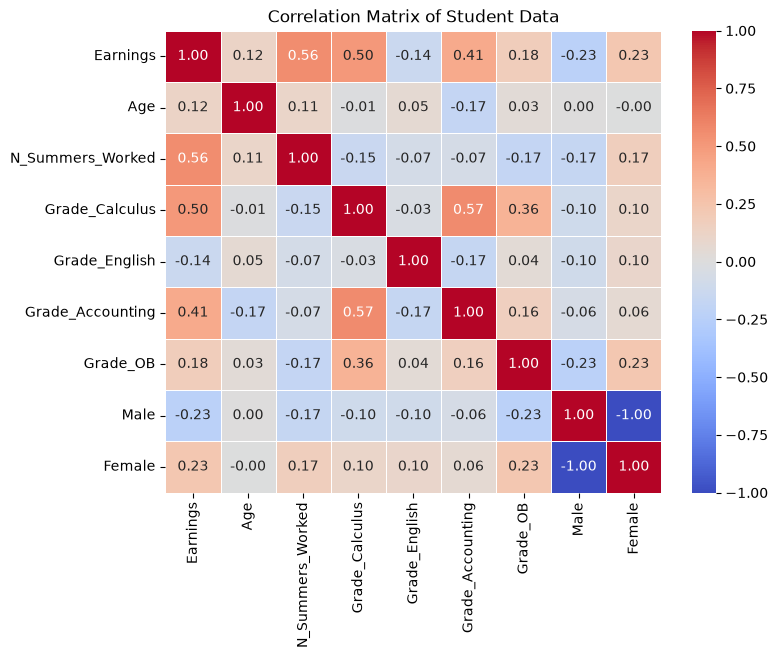

In [10]:
# Creating a heatmap to visualize the correlation matrix

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Student Data")
plt.show()

In [11]:
# We see high correlation between accounting and calculus grade, but that makes sense. Nothing too concerning for the time being.

In [12]:
# a

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Dependent variable: Earnings
# Independent variables: Age, Summers Worked, Grades, and Female (dropping Male to avoid dummy trap)
formula = 'Earnings ~ Age + N_Summers_Worked + Grade_Calculus + Grade_English + Grade_Accounting + Grade_OB + Female'

# Fit the Ordinary Least Squares (OLS) model using statsmodels formula api
model = smf.ols(formula=formula, data=data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     30.93
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.35e-21
Time:                        15:13:02   Log-Likelihood:                -752.72
No. Observations:                 100   AIC:                             1521.
Df Residuals:                      92   BIC:                             1542.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1854.3302   1498.242  

In [13]:
# Refined model formula dropping Grade_English and Grade_OB
refined_formula = 'Earnings ~ Age + N_Summers_Worked + Grade_Calculus + Grade_Accounting + Female'

# Fit the model
refined_model = smf.ols(formula=refined_formula, data=data).fit()

# Print summary
print(refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     42.52
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.09e-22
Time:                        15:13:02   Log-Likelihood:                -754.11
No. Observations:                 100   AIC:                             1520.
Df Residuals:                      94   BIC:                             1536.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1209.1672   1292.749  

In [14]:
# Final model formula dropping Age as well
final_formula = 'Earnings ~ N_Summers_Worked + Grade_Calculus + Grade_Accounting + Female'

# Fit the model
final_model = smf.ols(formula=final_formula, data=data).fit()

# Print summary
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     51.87
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           4.30e-23
Time:                        15:13:02   Log-Likelihood:                -755.31
No. Observations:                 100   AIC:                             1521.
Df Residuals:                      95   BIC:                             1534.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         3067.3669    401.997  

In [15]:
# Update the model to include interaction between Female and Grade_Calculus and Grade_Accounting

data['Female_Grade_Calculus'] = data['Female'] * data['Grade_Calculus']
data['Female_Grade_Accounting'] = data['Female'] * data['Grade_Accounting']

formula_with_interaction = 'Earnings ~ N_Summers_Worked + Grade_Calculus + Grade_Accounting + Female_Grade_Calculus + Female_Grade_Accounting'

# Fit the model
interaction_model = smf.ols(formula=formula_with_interaction, data=data).fit()

# Print summary
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     41.54
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           2.30e-22
Time:                        15:13:02   Log-Likelihood:                -754.92
No. Observations:                 100   AIC:                             1522.
Df Residuals:                      94   BIC:                             1537.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

In [16]:
# Same as above but with male for sanity check

data['Male_Grade_Calculus'] = data['Male'] * data['Grade_Calculus']
data['Male_Grade_Accounting'] = data['Male'] * data['Grade_Accounting']

formula_with_male_interaction = 'Earnings ~ N_Summers_Worked + Grade_Calculus + Grade_Accounting + Male_Grade_Calculus + Male_Grade_Accounting'

# Fit the model
male_interaction_model = smf.ols(formula=formula_with_male_interaction, data=data).fit()

# Print summary
print(male_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     41.54
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           2.30e-22
Time:                        15:13:02   Log-Likelihood:                -754.92
No. Observations:                 100   AIC:                             1522.
Df Residuals:                      94   BIC:                             1537.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3118.36

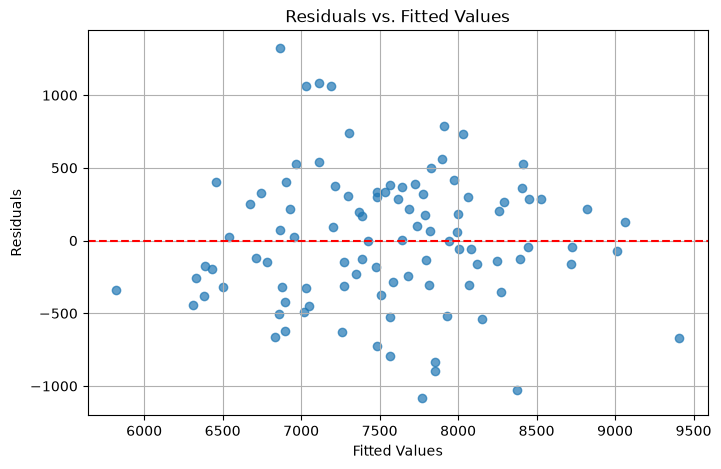

--- Breusch-Pagan Test Results ---
LM Statistic: 3.5573
LM p-value: 0.6147
F Statistic: 0.6934
F p-value: 0.6297


In [17]:
# b
# Check for heteroscedasticity using residuals vs fitted values plot and Breusch-Pagan test

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Residuals vs. Fitted Values Plot
fitted_vals = male_interaction_model.fittedvalues
residuals = male_interaction_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.grid(True)
plt.show()

# 2. Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, male_interaction_model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']

print("--- Breusch-Pagan Test Results ---")
for stat, value in zip(labels, bp_test):
    print(f"{stat}: {value:.4f}")

Both p-values greater 0.05 and graph does not show any specific pattern. No heteroskedasticity.

# c

There is approximately 36 dollar earning increase for every percent grade increase in calculus. However, that relationship does not necesarrily mean causation. It could be that people who work hard in general work hard in both finding a good job and in calculus. Furthermore, additional research is needed to justify costs. Do tutoring costs make sense considering the earnings increase? Maybe it is cheaper to just fund or provide a subsidy that boosts earnings directly.

In [18]:
# d

# Perform wald test on the interaction terms to check if they are jointly significant

hypothesis = 'Male_Grade_Calculus = 0, Male_Grade_Accounting = 0'

print(male_interaction_model.wald_test(hypothesis))

<F test: F=array([[1.00251319]]), p=0.3708450342406193, df_denom=94, df_num=2>


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [19]:
# We do not reject the null hypothesis, indicating that the interaction terms are not jointly significant. This suggests that the effect of grades on earnings does not differ significantly between males and females in this dataset.

In [20]:
#Kingston Real Estate Question

# Import data from excel file

data_path_kingston = os.path.join(curdir,'MMA_860_Final_Practice_Data_vf.xlsx')

kingston_data = pd.read_excel(data_path_kingston, sheet_name="3.KingstonRealEstate")

kingston_data.head()

,Obs,Price,N_Bedrooms,N_Bathrooms,House_Size,Age,Renovated_Kitchen,Finished_Basement,Close_to_Campus
0,1,309375,2,2,1887,31,0,1,0
1,2,335726,3,1,1699,27,0,0,1
2,3,429144,5,3,2939,38,0,0,0
3,4,509594,4,3,2651,21,0,0,1
4,5,404694,4,1,2550,48,0,1,1


In [21]:
# Drop obs column
kingston_data = kingston_data.drop(columns=['Obs'])

kingston_data.head()


,Price,N_Bedrooms,N_Bathrooms,House_Size,Age,Renovated_Kitchen,Finished_Basement,Close_to_Campus
0,309375,2,2,1887,31,0,1,0
1,335726,3,1,1699,27,0,0,1
2,429144,5,3,2939,38,0,0,0
3,509594,4,3,2651,21,0,0,1
4,404694,4,1,2550,48,0,1,1


Question a

For univariate outliers, we can simply look at records that sit outside 3 standard deviations from the mean. For multivariate outliers, we can use an influence plot that combines leverage residuals and Cook's distance plot into one. We want to look for large circles above 3 or below -3, especially those sitting on the far right meaning they have high leverage (massive potential to tilt regression). The size of the circle shows influence.
The decision to keep or delete is based on two factors: if it is an error, delete it or fix it (see missing observations). If it is not an error, but it is in-scope for your analysis, retain it. If not, delete it. Either way, you will need to state your assumptions.

Question b

The correct approach depends on whether the data is MCAR, MAR, or MNAR. If data is MCAR, I can often remove incomplete observations without introducing bias. If data is MAR, the preferred approach is multiple imputation because the missingness can be explained using observed variables. If data is MNAR, there is no perfect statistical fix because the missingness depends on the missing value itself, so results should be interpreted cautiously and sensitivity analyses should be considered.


In [ ]:
# Question c

# Build model with all variables from kingston_data

kingston_model_formula = "Price ~ N_Bedrooms + N_Bathrooms + House_Size"
kingston_model = smf.